In [1]:
import os
import ast
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from tqdm import tqdm

<jemalloc>: Unsupported system page size


In [2]:
# Base path
path = "/datasets/multi-view-pig-posture-recognition"
train2_path = f"{path}/train2.csv"
train2_images_path = f"{path}/train2_images"
test_path = f"{path}/test.csv"
test_images_path = f"{path}/test_images"
sample_submission_path = f"{path}/sample_submission.csv"
txt_path = f"{path}/pig_posture_classes.txt"

# Load CSVs
train_df = pd.read_csv(train2_path)
test_df = pd.read_csv(test_path)
sample_submission = pd.read_csv(sample_submission_path)

# Load class labels
with open(txt_path, "r") as f:
    classes = [line.strip() for line in f.readlines()]

print(f"Classes: {classes}")
print(f"Train samples: {len(train_df)}, Test samples: {len(test_df)}")
train_df.head()

Classes: ['Lateral_lying_left', 'Lateral_lying_right', 'Sitting', 'Standing', 'Sternal_lying']
Train samples: 23450, Test samples: 11708


,row_id,image_id,width,height,bbox,class_id
0,train_pen1_orb_cam1_20250108_085204_0000,pen1_orb_cam1_20250108_085204.jpg,1920,1080,"[1031.5,368.0,349.0,435.0]",0
1,train_pen1_orb_cam1_20250108_085204_0001,pen1_orb_cam1_20250108_085204.jpg,1920,1080,"[1278.5,428.0,233.0,438.0]",4
2,train_pen1_orb_cam1_20250108_085204_0002,pen1_orb_cam1_20250108_085204.jpg,1920,1080,"[732.0,137.5,342.0,198.0]",1
3,train_pen1_orb_cam1_20250108_085204_0003,pen1_orb_cam1_20250108_085204.jpg,1920,1080,"[830.0,169.0,370.0,263.0]",0
4,train_pen1_orb_cam1_20250108_085204_0004,pen1_orb_cam1_20250108_085204.jpg,1920,1080,"[611.5,314.8,381.5,386.6]",3


In [3]:
TRAIN_IMG_DIR = train2_images_path
TEST_IMG_DIR = test_images_path

In [4]:
print("Unique train images: ", train_df["image_id"].nunique())
print("Unique test images: ", test_df["image_id"].nunique())

print("Train instances: ", len(train_df))
print("Test instances: ", len(test_df))

Unique train images:  3150
Unique test images:  1350
Train instances:  23450
Test instances:  11708


class_id
0    3083
1    3435
2     695
3    9928
4    6309
Name: count, dtype: int64


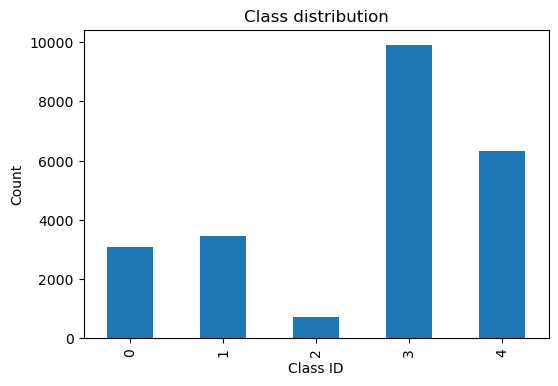

In [5]:
#Class distribution

class_counts = train_df["class_id"].value_counts().sort_index()

print(class_counts)

plt.figure(figsize=(6, 4))
class_counts.plot(kind="bar")
plt.title("Class distribution")
plt.xlabel("Class ID")
plt.ylabel("Count")
plt.show()

In [6]:
#Bounding box analysis

def parse_bbox(bbox_str):
    return ast.literal_eval(bbox_str)

train_df["parsed_bbox"] = train_df["bbox"].apply(parse_bbox)

train_df[["xmin", "ymin", "w", "h"]] = pd.DataFrame(
    train_df["parsed_bbox"].tolist(),
    index = train_df.index
)

train_df["area"] = train_df["w"] * train_df["h"]

print("BBox Width stats:")
print(train_df['w'].describe())

print("\nBBox height stats:")
print(train_df["h"].describe())

print("\nBBox area stats:")
print(train_df["area"].describe())

BBox Width stats:
count    23450.000000
mean       300.014670
std        147.973854
min         44.400000
25%        187.000000
50%        281.000000
75%        383.000000
max       1120.000000
Name: w, dtype: float64

BBox height stats:
count    23450.000000
mean       295.973906
std        141.796523
min         75.000000
25%        188.925000
50%        258.150000
75%        395.000000
max       1164.000000
Name: h, dtype: float64

BBox area stats:
count     23450.000000
mean      95399.564287
std       82868.543783
min        6900.320000
25%       45640.402500
50%       70118.500000
75%      110339.500000
max      763617.000000
Name: area, dtype: float64


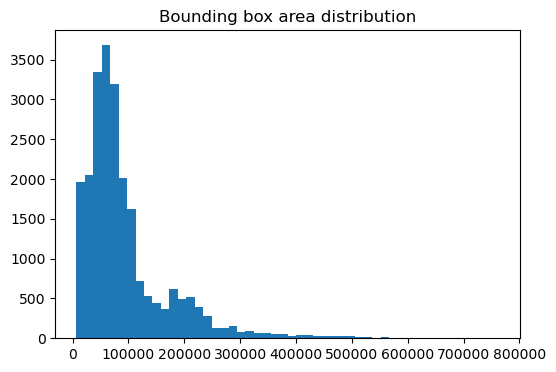

In [7]:
#BBox size distribution

plt.figure(figsize=(6,4))
plt.hist(train_df["area"], bins=50)
plt.title("Bounding box area distribution")
plt.show()

Mean pig per image:  7.444444444444445
Max pig in one image:  11


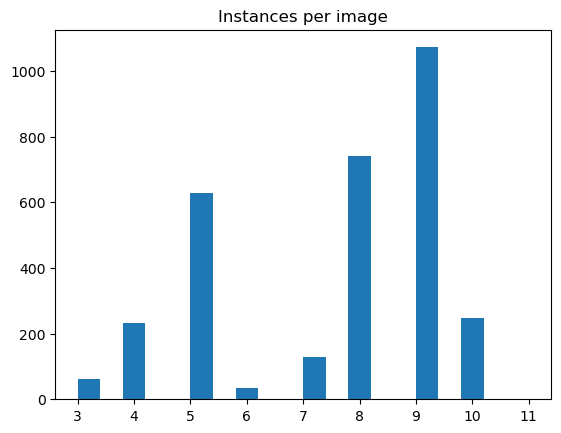

In [8]:
#Instances per images

instances_per_image = train_df.groupby("image_id").size()

print("Mean pig per image: ", instances_per_image.mean())
print("Max pig in one image: ", instances_per_image.max())

plt.hist(instances_per_image, bins=20)
plt.title("Instances per image")
plt.show()

In [9]:
#Image resolution check

image_size = []

for img_name in tqdm(train_df["image_id"].unique()):
    img_path = os.path.join(TRAIN_IMG_DIR, img_name)
    img = cv2.imread(img_path)
    if img is not None:
        h, w = img.shape[:2]
        image_size.append((w, h))

image_size = pd.DataFrame(
    image_size,
    columns = ["width", "height"]
)

print("Image size:\n ",image_size.describe())

100%|██████████| 3150/3150 [01:16<00:00, 41.00it/s]

Image size:
               width       height
count  3150.000000  3150.000000
mean   1611.946667   907.225397
std     413.067697   233.671967
min    1280.000000   720.000000
25%    1280.000000   720.000000
50%    1280.000000   720.000000
75%    1920.000000  1080.000000
max    2688.000000  1520.000000


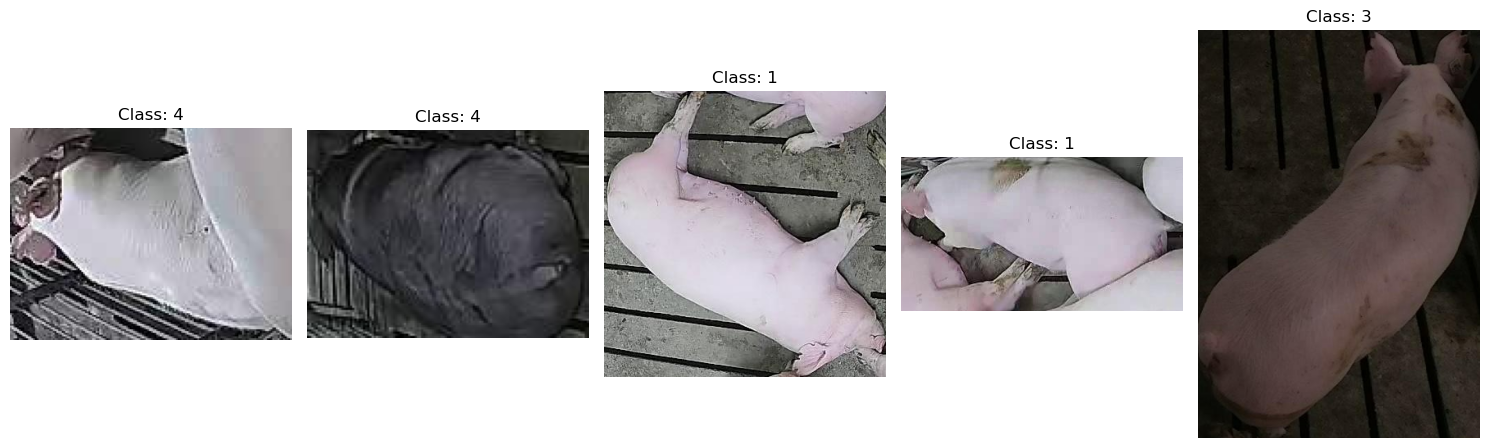

In [11]:
#Cropped instances

def show_random_samples(df, num_samples=5):
    samples = df.sample(num_samples)

    plt.figure(figsize=(15, 5))

    for i, (_, row) in enumerate(samples.iterrows()):
        img_path = os.path.join(TRAIN_IMG_DIR, row["image_id"])
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        xmin, ymin, w, h = row["xmin"], row["ymin"], row["w"], row["h"]
        crop = img[int(ymin):int(ymin+h), int(xmin):int(xmin+w)]

        plt.subplot(1, num_samples, i+1)
        plt.imshow(crop)
        plt.title(f"Class: {row['class_id']}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

show_random_samples(train_df, 5)

In [12]:
!pip install timm -q

In [13]:
import os
import ast
import cv2
import numpy as np
import pandas as pd
import random
from tqdm import tqdm
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import f1_score

import albumentations as A
from albumentations.pytorch import ToTensorV2

import timm

In [14]:
class CFG:
    IMG_SIZE = 300
    BATCH_SIZE = 16
    EPOCHS = 15          # increased from 5
    LR = 3e-4
    WEIGHT_DECAY = 1e-4  # added
    NUM_CLASSES = 5
    DEVICE = "cuda:2"
    SEED = 42
    N_FOLDS = 5

In [15]:
#Seed Everything

def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(CFG.SEED)

In [16]:
# Verify paths exist
for p in [TRAIN_CSV, TEST_CSV, SAMPLE_SUB_CSV, CLASS_TXT, TRAIN_IMG_DIR, TEST_IMG_DIR]:
    exists = "✓" if os.path.exists(p) else "✗ MISSING"
    print(f"  {exists}  {p}")

train_df = pd.read_csv(TRAIN_CSV)
test_df = pd.read_csv(TEST_CSV)
sample_submission = pd.read_csv(SAMPLE_SUB_CSV)

with open(CLASS_TXT, "r") as f:
    classes = [line.strip() for line in f.readlines()]

print(f"Classes: {classes}")
print(f"Train samples: {len(train_df)}, Test samples: {len(test_df)}")
train_df.head()

  ✓  /datasets/multi-view-pig-posture-recognition/train2.csv
  ✓  /datasets/multi-view-pig-posture-recognition/test.csv
  ✓  /datasets/multi-view-pig-posture-recognition/sample_submission.csv
  ✓  /datasets/multi-view-pig-posture-recognition/pig_posture_classes.txt
  ✓  /datasets/multi-view-pig-posture-recognition/train2_images
  ✓  /datasets/multi-view-pig-posture-recognition/test_images
Classes: ['Lateral_lying_left', 'Lateral_lying_right', 'Sitting', 'Standing', 'Sternal_lying']
Train samples: 23450, Test samples: 11708


,row_id,image_id,width,height,bbox,class_id
0,train_pen1_orb_cam1_20250108_085204_0000,pen1_orb_cam1_20250108_085204.jpg,1920,1080,"[1031.5,368.0,349.0,435.0]",0
1,train_pen1_orb_cam1_20250108_085204_0001,pen1_orb_cam1_20250108_085204.jpg,1920,1080,"[1278.5,428.0,233.0,438.0]",4
2,train_pen1_orb_cam1_20250108_085204_0002,pen1_orb_cam1_20250108_085204.jpg,1920,1080,"[732.0,137.5,342.0,198.0]",1
3,train_pen1_orb_cam1_20250108_085204_0003,pen1_orb_cam1_20250108_085204.jpg,1920,1080,"[830.0,169.0,370.0,263.0]",0
4,train_pen1_orb_cam1_20250108_085204_0004,pen1_orb_cam1_20250108_085204.jpg,1920,1080,"[611.5,314.8,381.5,386.6]",3


In [17]:
train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.2),
    A.RandomBrightnessContrast(p=0.5),
    A.CLAHE(p=0.3),
    A.HueSaturationValue(p=0.3),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1, rotate_limit=15, p=0.5),
    A.CoarseDropout(max_holes=8, max_height=32, max_width=32, p=0.3),
    A.Resize(CFG.IMG_SIZE, CFG.IMG_SIZE),
    A.Normalize(),
    ToTensorV2()
])

valid_transform = A.Compose([
    A.Resize(CFG.IMG_SIZE, CFG.IMG_SIZE),
    A.Normalize(),
    ToTensorV2()
])

In [40]:
class PigModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = timm.create_model(
            "efficientnet_b3",
            pretrained=True,
            num_classes=0
        )
        num_features = self.backbone.num_features  # dynamic, not hardcoded 1536
        self.dropout = nn.Dropout(0.4)
        self.fc = nn.Linear(num_features, CFG.NUM_CLASSES)

    def forward(self, x):
        x = self.backbone(x)
        x = self.dropout(x)
        x = self.fc(x)
        return x

In [41]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.ce = nn.CrossEntropyLoss(reduction="none")

    def forward(self, logits, targets):
        ce_loss = self.ce(logits, targets)
        pt = torch.exp(-ce_loss)
        if self.alpha is not None:
            at = self.alpha.gather(0, targets)
            ce_loss = ce_loss * at
        loss = ((1 - pt) ** self.gamma) * ce_loss
        return loss.mean()

# Use FocalLoss with class weights
class_counts = train_df["class_id"].value_counts().sort_index()
weights = len(train_df) / (CFG.NUM_CLASSES * class_counts)
weights = torch.tensor(weights.values, dtype=torch.float).to(CFG.DEVICE)

criterion = FocalLoss(alpha=weights, gamma=2)

In [ ]:
from torch.cuda.amp import GradScaler, autocast

skf = StratifiedGroupKFold(n_splits=CFG.N_FOLDS, shuffle=True, random_state=CFG.SEED)

fold_models = []

for fold, (train_idx, val_idx) in enumerate(
    skf.split(train_df, train_df["class_id"], groups=train_df["image_id"])
):
    print(f"\n=============== FOLD {fold+1} =======================")

    train_dataset = PigDataset(train_df.iloc[train_idx], TRAIN_IMG_DIR, train_transform)
    val_dataset = PigDataset(train_df.iloc[val_idx], TRAIN_IMG_DIR, valid_transform)

    train_loader = DataLoader(train_dataset, batch_size=CFG.BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=True)
    val_loader = DataLoader(val_dataset, batch_size=CFG.BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)

    model = PigModel().to(CFG.DEVICE)
    optimizer = optim.AdamW(model.parameters(), lr=CFG.LR, weight_decay=CFG.WEIGHT_DECAY)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CFG.EPOCHS)
    scaler = GradScaler()

    best_f1 = 0
    patience_counter = 0
    patience = 3  # early stopping patience
    save_path = f"best_model_fold{fold}.pth"

    for epoch in range(CFG.EPOCHS):
        # --- Train ---
        model.train()
        running_loss = 0.0

        for imgs, labels in tqdm(train_loader, desc=f"Fold {fold+1} Epoch {epoch+1} [Train]"):
            imgs, labels = imgs.to(CFG.DEVICE), labels.to(CFG.DEVICE)
            optimizer.zero_grad()
            with autocast():
                outputs = model(imgs)
                loss = criterion(outputs, labels)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            running_loss += loss.item()

        scheduler.step()

        # --- Validate ---
        model.eval()
        val_preds, val_true = [], []

        with torch.no_grad():
            for imgs, labels in tqdm(val_loader, desc=f"Fold {fold+1} Epoch {epoch+1} [Val]"):
                imgs = imgs.to(CFG.DEVICE)
                outputs = model(imgs)
                val_preds.extend(torch.argmax(outputs, dim=1).cpu().numpy())
                val_true.extend(labels.numpy())

        f1 = f1_score(val_true, val_preds, average="macro")
        avg_loss = running_loss / len(train_loader)
        print(f"Epoch {epoch+1} | Loss: {avg_loss:.4f} | Val F1: {f1:.4f}")

        if f1 > best_f1:
            best_f1 = f1
            patience_counter = 0
            torch.save(model.state_dict(), save_path)
            print(f"  → Saved best model (F1={f1:.4f})")
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"  → Early stopping at epoch {epoch+1}")
                break

    print(f"Fold {fold+1} best F1: {best_f1:.4f}")
    fold_models.append(save_path)

['row_id', 'image_id', 'width', 'height', 'bbox', 'class_id']
                                     row_id  \
0  train_pen1_orb_cam1_20250108_085204_0000   
1  train_pen1_orb_cam1_20250108_085204_0001   

                            image_id  width  height  \
0  pen1_orb_cam1_20250108_085204.jpg   1920    1080   
1  pen1_orb_cam1_20250108_085204.jpg   1920    1080   

                         bbox  class_id  
0  [1031.5,368.0,349.0,435.0]         0  
1  [1278.5,428.0,233.0,438.0]         4  

===============FOLD 1=======================


100%|██████████| 293/293 [00:26<00:00, 11.23it/s]


Epoch 1 | F1: 0.7441


 57%|█████▋    | 664/1173 [01:47<01:20,  6.29it/s]

In [ ]:
# --- 1. Patched PigDataset (with test mode) ---

class PigDataset(Dataset):
    def __init__(self, df, img_dir, transform=None, is_test=False):
        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform
        self.is_test = is_test

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.img_dir, row["image_id"])
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        bbox = row["bbox"]
        if isinstance(bbox, str):
            bbox = ast.literal_eval(bbox)
        xmin, ymin, w, h = [int(v) for v in bbox]

        H, W = img.shape[:2]
        x1, y1 = max(0, xmin), max(0, ymin)
        x2, y2 = min(W, xmin + w), min(H, ymin + h)
        crop = img[y1:y2, x1:x2]

        if crop.size == 0:
            crop = img

        if self.transform:
            crop = self.transform(image=crop)["image"]

        if self.is_test:
            return crop
        return crop, int(row["class_id"])


# --- 2. Build test loader ---

test_dataset = PigDataset(test_df, TEST_IMG_DIR, valid_transform, is_test=True)
test_loader = DataLoader(
    test_dataset, batch_size=CFG.BATCH_SIZE, shuffle=False,
    num_workers=4, pin_memory=True
)

# --- 3. Collect fold models ---

import glob
fold_models = sorted(glob.glob("best_model_fold*.pth"))
print(f"Found {len(fold_models)} fold models: {fold_models}")
assert len(fold_models) > 0, "No saved models found!"

# --- 4. Inference with TTA ---

all_fold_preds = []

for fold_path in fold_models:
    print(f"Inferring with {fold_path}...")
    model = PigModel().to(CFG.DEVICE)
    model.load_state_dict(torch.load(fold_path, map_location=CFG.DEVICE, weights_only=True))
    model.eval()

    fold_probs = []
    with torch.no_grad(), torch.cuda.amp.autocast():
        for imgs in tqdm(test_loader):
            imgs = imgs.to(CFG.DEVICE)
            probs1 = torch.softmax(model(imgs), dim=1)
            probs2 = torch.softmax(model(torch.flip(imgs, dims=[3])), dim=1)
            fold_probs.append(((probs1 + probs2) / 2).cpu().numpy())

    all_fold_preds.append(np.concatenate(fold_probs))

# --- 5. Ensemble & submission ---

final_probs = np.mean(all_fold_preds, axis=0)
final_preds = np.argmax(final_probs, axis=1)

submission = pd.DataFrame({
    "row_id": test_df["row_id"],
    "class_id": final_preds
})
print(submission["class_id"].value_counts())
submission.to_csv("submission.csv", index=False)
print(f"Submission saved: {len(submission)} rows")
submission.head()